# H2: Mitigating format sensitivity

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from fsr.formats import FORMAT_NAMES
from fsr.h2_results import (
    answer_table,
    available,
    correlation,
    guardrail_frame,
    load_selection,
    per_fold_matrix,
    score_table,
    selection_counts,
    selection_table,
    transfer_frame,
    weight_frame,
    winner_weight,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 100,
        "grid.linewidth": 0.6,
        "grid.alpha": 0.45,
        "axes.edgecolor": "0.3",
        "axes.linewidth": 0.9,
    }
)

BAR_FILL = sns.color_palette("pastel")[0]
BAR_EDGE = sns.color_palette("muted")[0]
MUTED_FILL = "0.88"
MUTED_EDGE = "0.6"
RULE = "0.35"
ERROR = "0.45"
DIVERGING = "RdBu_r"

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
DATA_ROOT = ROOT / "data" / "nq"
FIG_DIR = ROOT / "notebooks" / "h2" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

HELD_OUT = "ood"
IN_TRAINING = "in_training"
WEIGHTS = ("0", "0.01", "0.1", "1", "10")
WEIGHT_LABEL = "invariance weight (\u03bb)"


def save(fig, name):
    """Write the figure as a vector PDF for the thesis and a PNG to read."""
    fig.tight_layout()
    for suffix in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{suffix}", bbox_inches="tight")


def fills(flags):
    """Return the fill and edge colour of each bar, by whether it resolved."""
    return (
        [BAR_FILL if f else MUTED_FILL for f in flags],
        [BAR_EDGE if f else MUTED_EDGE for f in flags],
    )


SLUGS = available(DATA_ROOT)
WINNER = {s: winner_weight(load_selection(DATA_ROOT, s)) for s in SLUGS}
scores = score_table(DATA_ROOT, SLUGS, subset=HELD_OUT)
answers = answer_table(DATA_ROOT, SLUGS, subset=HELD_OUT)
scores_in = score_table(DATA_ROOT, SLUGS, subset=IN_TRAINING)
answers_in = answer_table(DATA_ROOT, SLUGS, subset=IN_TRAINING)

print(f"{len(SLUGS)} models, {len(FORMAT_NAMES)} folds, two arms each")
print("winner: " + ", ".join(f"{s}={WINNER[s]:g}" for s in SLUGS))

6 models, 5 folds, two arms each
winner: minilm_l6=1, minilm_l12=0.1, bge_base=1, bge_v2_m3=1, mxbai_v1=0.1, jina_v2=0.1


## Phase 1: choosing the invariance weight

In [2]:
selection_table(DATA_ROOT, SLUGS).round(3)

,baseline,0,0.01,0.1,1,10,winner
model,,,,,,,
MiniLM-L6,0.936,0.380,0.383,0.248,0.226,0.187,1
MiniLM-L12,0.918,0.284,0.266,0.239,0.225,0.126,0.1
bge-base,0.295,0.351,0.310,0.185,0.145,0.078,1
bge-v2-m3,0.450,0.362,0.248,0.126,0.092,0.089,1
mxbai-v1,0.642,0.225,0.138,0.081,0.146,0.047,0.1
jina-v2,0.809,0.261,0.225,0.099,0.165,0.130,0.1


In [3]:
counts = selection_counts(DATA_ROOT, SLUGS)
print(f"ranking guardrail: {counts['passed']}/{counts['candidates']} candidates pass")
print("tie-break fired on: " + ", ".join(counts["tie_broken"]))

ranking guardrail: 30/30 candidates pass
tie-break fired on: MiniLM-L6, MiniLM-L12, bge-base, bge-v2-m3, mxbai-v1, jina-v2


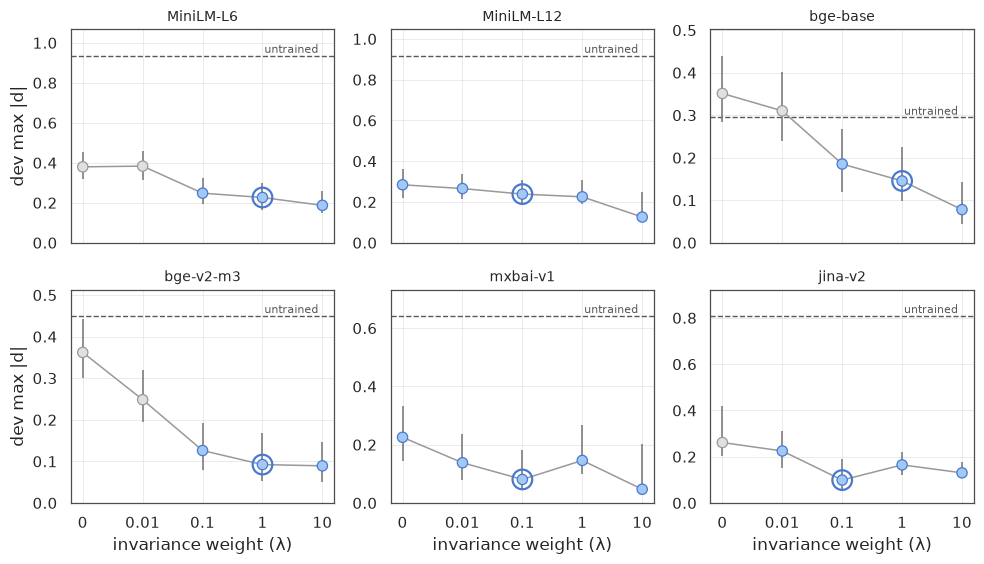

In [4]:
table = selection_table(DATA_ROOT, SLUGS)
x = np.arange(len(WEIGHTS))

fig, axs = plt.subplots(2, 3, figsize=(10, 5.8), sharex=True)
for ax, slug, label in zip(axs.flat, SLUGS, table.index, strict=True):
    frame = weight_frame(DATA_ROOT, slug)
    baseline = table.loc[label, "baseline"]
    fill, edge = fills(frame["tied"])

    ax.axhline(baseline, color=RULE, ls="--", lw=1, zorder=1)
    ax.text(
        len(WEIGHTS) - 1,
        baseline,
        "untrained ",
        color=RULE,
        fontsize=8,
        ha="right",
        va="bottom",
    )
    ax.plot(x, frame["max_abs_d"], lw=1.1, color=MUTED_EDGE, zorder=2)
    ax.vlines(x, frame["ci_lo"], frame["ci_hi"], color=ERROR, lw=1.1, zorder=3)
    ax.scatter(
        x, frame["max_abs_d"], s=55, c=fill, edgecolors=edge, linewidths=0.9, zorder=4
    )
    pick = int(np.flatnonzero(frame["winner"].to_numpy())[0])
    ax.scatter(
        [pick],
        [frame["max_abs_d"].iloc[pick]],
        s=200,
        facecolors="none",
        edgecolors=BAR_EDGE,
        linewidths=1.6,
        zorder=5,
    )

    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, max(baseline, frame["ci_hi"].max()) * 1.14)
    ax.set_xticks(x)
    ax.set_xticklabels(WEIGHTS)

for ax in axs[:, 0]:
    ax.set_ylabel("dev max |d|")
for ax in axs[-1]:
    ax.set_xlabel(WEIGHT_LABEL)
save(fig, "phase1_weight_sweep")

bge-base is the only model whose rank-only control is more format-sensitive than
the untrained checkpoint, at 0.351 against 0.295. LoRA fine-tuning alone
therefore raises its score-magnitude sensitivity, and the reduction it reaches at
the selected weight is attributable to the invariance term rather than to
adaptation in general.

## Score axis

In [5]:
scores[
    [
        "weight",
        "baseline_max_d",
        "control_max_d",
        "trained_max_d",
        "delta",
        "ci_lo",
        "ci_hi",
        "folds_improved",
        "mean_mrr",
    ]
].round(3)

,weight,baseline_max_d,control_max_d,trained_max_d,delta,ci_lo,ci_hi,folds_improved,mean_mrr
model,,,,,,,,,
MiniLM-L6,1.0,0.903,0.469,0.393,-0.076,-0.112,-0.029,3,0.942
MiniLM-L12,0.1,0.938,0.262,0.164,-0.098,-0.133,-0.045,4,0.959
bge-base,1.0,0.383,0.360,0.148,-0.212,-0.265,-0.146,5,0.962
bge-v2-m3,1.0,0.452,0.331,0.113,-0.218,-0.259,-0.154,5,0.974
mxbai-v1,0.1,0.651,0.220,0.156,-0.064,-0.092,-0.015,3,0.968
jina-v2,0.1,0.896,0.229,0.125,-0.104,-0.139,-0.071,5,0.974


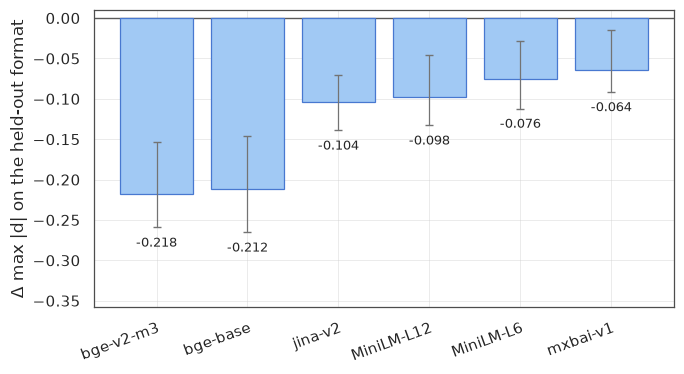

In [6]:
order = scores.sort_values("delta").index
point = scores.loc[order, "delta"]
err = [point - scores.loc[order, "ci_lo"], scores.loc[order, "ci_hi"] - point]
fill, edge = fills(scores.loc[order, "excludes_zero"])

fig, ax = plt.subplots(figsize=(7, 3.9))
ax.bar(
    order,
    point,
    zorder=2,
    color=fill,
    edgecolor=edge,
    linewidth=0.9,
    yerr=err,
    capsize=3,
    error_kw={"lw": 0.9, "ecolor": ERROR, "zorder": 3},
)
for x, (value, low) in enumerate(zip(point, scores.loc[order, "ci_lo"], strict=True)):
    ax.text(x, low - 0.012, f"{value:.3f}", ha="center", va="top", fontsize=9)

ax.axhline(0, color=RULE, lw=1, zorder=1)
ax.set_ylabel("\u0394 max |d| on the held-out format")
ax.set_xlabel("")
ax.set_ylim(scores["ci_lo"].min() * 1.35, 0.01)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", rotation_mode="anchor")
save(fig, "score_axis_delta")

The invariance term reduces out-of-distribution maximum |d| on all six models, by
0.064 (mxbai-v1) to 0.218 (bge-v2-m3), with every paired bootstrap interval
excluding zero. The reduction is measured against the rank-only control, so it is
the contribution of the invariance term and not of LoRA fine-tuning. The
direction is uniform across the set and the magnitude is not.

## Answer axis

In [7]:
answers[
    [
        "weight",
        "n_pool",
        "control_pct",
        "trained_pct",
        "delta_pp",
        "ci_lo",
        "ci_hi",
        "excludes_zero",
    ]
].round(2)

,weight,n_pool,control_pct,trained_pct,delta_pp,ci_lo,ci_hi,excludes_zero
model,,,,,,,,
MiniLM-L6,1.0,674,0.95,0.36,-0.59,-0.97,-0.24,True
MiniLM-L12,0.1,687,1.19,0.76,-0.44,-0.81,-0.09,True
bge-base,1.0,696,0.83,0.32,-0.52,-0.84,-0.20,True
bge-v2-m3,1.0,730,0.30,0.14,-0.16,-0.38,0.03,False
mxbai-v1,0.1,693,0.14,0.14,0.00,-0.12,0.12,False
jina-v2,0.1,715,0.22,0.25,0.03,-0.14,0.22,False


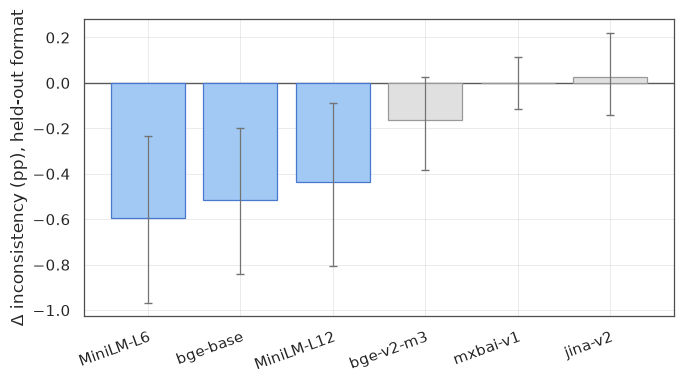

In [8]:
order = answers.sort_values("delta_pp").index
point = answers.loc[order, "delta_pp"]
err = [point - answers.loc[order, "ci_lo"], answers.loc[order, "ci_hi"] - point]
fill, edge = fills(answers.loc[order, "excludes_zero"])

fig, ax = plt.subplots(figsize=(7, 3.9))
ax.bar(
    order,
    point,
    zorder=2,
    color=fill,
    edgecolor=edge,
    linewidth=0.9,
    yerr=err,
    capsize=3,
    error_kw={"lw": 0.9, "ecolor": ERROR, "zorder": 3},
)
ax.axhline(0, color=RULE, lw=1, zorder=1)
ax.set_ylabel("\u0394 inconsistency (pp), held-out format")
ax.set_xlabel("")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", rotation_mode="anchor")
save(fig, "answer_axis_delta")

Three models reduce conditional inconsistency with intervals excluding zero:
MiniLM-L6 (-0.59 pp), bge-base (-0.52) and MiniLM-L12 (-0.44). bge-v2-m3,
mxbai-v1 and jina-v2 do not move. The answer axis therefore separates the set
where the score axis does not, and narrowing the spread of the scores does not by
itself change which passage ranks first.

## Ranking quality

guardrail: 30/30 arms pass at margin -0.03
lowest interval bound: +0.0047


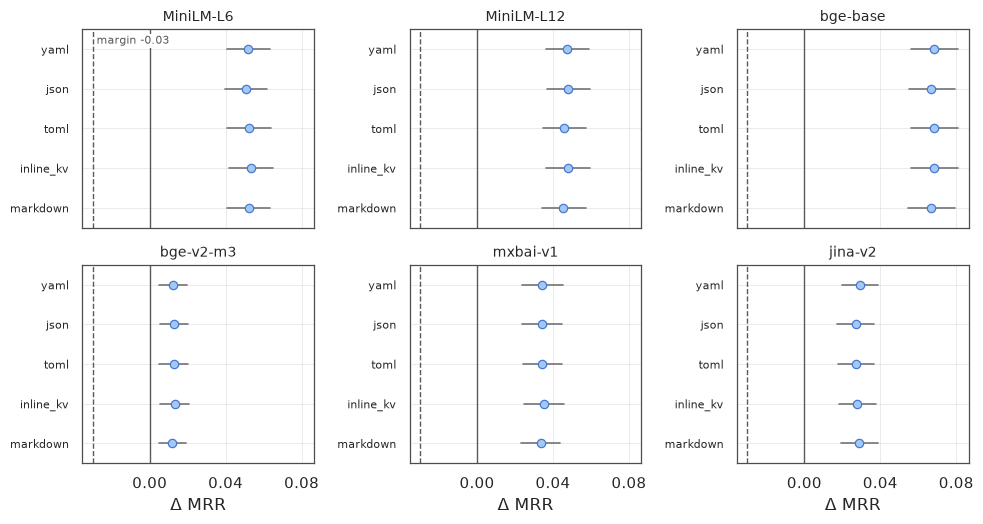

In [9]:
guard = guardrail_frame(DATA_ROOT, SLUGS)
margin = guard["margin"].iloc[0]
y = np.arange(len(FORMAT_NAMES))

fig, axs = plt.subplots(2, 3, figsize=(10, 5.4), sharex=True)
for ax, label in zip(axs.flat, scores.index, strict=True):
    block = guard.loc[label].loc[list(FORMAT_NAMES)]
    ax.axvline(0, color=RULE, lw=1, zorder=1)
    ax.axvline(-margin, color=RULE, ls="--", lw=1, zorder=1)
    for row, (_, entry) in enumerate(block.iterrows()):
        ax.plot(
            [entry["ci_lo"], entry["ci_hi"]], [row, row], color=ERROR, lw=1.2, zorder=2
        )
        ax.plot(
            [entry["delta_mrr"]],
            [row],
            marker="o",
            ms=6,
            mfc=BAR_FILL,
            mec=BAR_EDGE,
            mew=0.9,
            zorder=3,
        )
    ax.set_title(label, fontsize=10)
    ax.set_yticks(y)
    ax.set_yticklabels(FORMAT_NAMES, fontsize=8)
    ax.set_ylim(len(FORMAT_NAMES) - 0.5, -0.5)

for ax in axs.flat:
    ax.set_xticks([0.0, 0.04, 0.08])
for ax in axs[-1]:
    ax.set_xlabel("\u0394 MRR")
axs[0, 0].text(
    -margin + 0.002,
    -0.35,
    f"margin {-margin:g}",
    color=RULE,
    fontsize=8,
    ha="left",
    va="top",
    bbox={"facecolor": "white", "edgecolor": "none", "pad": 1},
)
save(fig, "ranking_quality")

passes = int(guard["passed"].sum())
print(f"guardrail: {passes}/{len(guard)} arms pass at margin {-margin:g}")
print(f"lowest interval bound: {guard['ci_lo'].min():+.4f}")

All thirty arms improve mean reciprocal rank against the untrained model, the
lowest interval bound among them being +0.005, and every candidate in the weight
sweep passed the same guardrail. No arm approaches the -0.03 margin, so the
invariance gain is not bought with ranking quality anywhere in the set.

## Transfer to the held-out format

$T$ is the reduction on the held-out format divided by the reduction on the
formats trained on, so $T = 1$ is equal gain on both and $T > 1$ is more on the
unseen format.

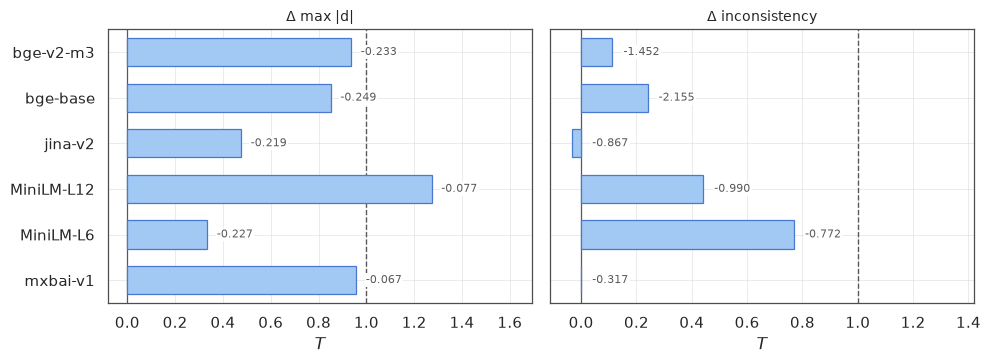

In [10]:
panels = [
    (scores_in["delta"], scores["delta"], "max |d|"),
    (answers_in["delta_pp"], answers["delta_pp"], "inconsistency"),
]
order = list(scores.sort_values("delta").index)
y = np.arange(len(order))

fig, axs = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, (in_training, held_out, label) in zip(axs, panels, strict=True):
    ratio = (held_out / in_training).loc[order]
    ax.barh(
        y,
        ratio,
        height=0.62,
        color=BAR_FILL,
        edgecolor=BAR_EDGE,
        linewidth=0.9,
        zorder=2,
    )
    ax.axvline(0, color=RULE, lw=0.9, zorder=1)
    ax.axvline(1, color=RULE, ls="--", lw=1, zorder=1)
    for row, model in enumerate(order):
        ax.text(
            max(ratio.iloc[row], 0) + 0.04,
            row,
            f"{in_training[model]:+.3f}",
            va="center",
            fontsize=8,
            color=RULE,
            bbox={"facecolor": "white", "edgecolor": "none", "pad": 1},
        )
    ax.set_xlim(min(ratio.min(), 0) - 0.08, max(ratio.max(), 1) + 0.42)
    ax.set_title(f"\u0394 {label}", fontsize=10)
    ax.set_xlabel("$T$")

axs[0].set_yticks(y)
axs[0].set_yticklabels(order)
axs[0].set_ylim(len(order) - 0.5, -0.5)
save(fig, "transfer")

In [11]:
transfer_frame(DATA_ROOT, SLUGS).groupby("model", sort=False)[
    ["delta_mrr", "training_mean", "transfer_ratio"]
].mean().loc[scores.index].round(3)

,delta_mrr,training_mean,transfer_ratio
model,,,
MiniLM-L6,0.050,0.053,0.956
MiniLM-L12,0.045,0.047,0.955
bge-base,0.068,0.068,1.029
bge-v2-m3,0.012,0.013,1.020
mxbai-v1,0.035,0.034,1.011
jina-v2,0.028,0.028,0.991


Held-out $\Delta$MRR matches the training-format mean on every model, at ratios
of 0.96 to 1.03, so ranking quality on the unseen format is indistinguishable
from ranking quality on the formats trained on. $T$ spans 0.33 to 1.27 on the
score axis and stays below 0.8 on the answer axis for all six. Ranking capability
therefore transfers in full and invariance does not.

## Both axes

In [12]:
matched = scores[["delta"]].join(answers[["delta_pp"]])
mixed = scores[["delta"]].join(
    answer_table(DATA_ROOT, SLUGS, subset="all_formats")[["delta_pp"]]
)
for name, frame in (("held-out", matched), ("all-format", mixed)):
    r = correlation(frame, "delta", "delta_pp")
    print(f"score held-out vs answer {name:<10} r = {r:+.3f}")

score held-out vs answer held-out   r = +0.147
score held-out vs answer all-format r = +0.772


Measured on the held-out format on both axes the two responses correlate at
r = +0.147. Pairing the held-out score axis against the all-format answer axis
gives +0.772. The agreement between the axes is an artefact of comparing
generalisation on one against in-training behaviour on the other, and at n = 6
neither coefficient is informative alone.

## Per fold

### Score axis

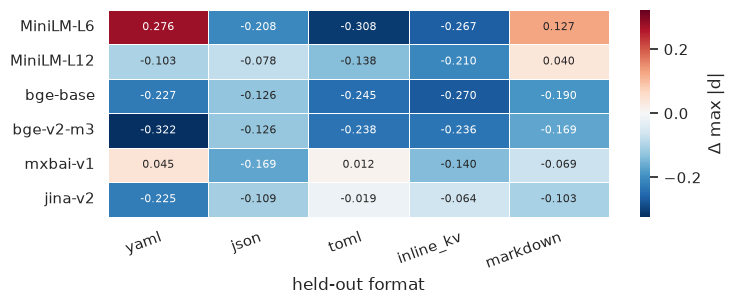

In [13]:
grid = per_fold_matrix(DATA_ROOT, SLUGS, "score", subset=HELD_OUT)
limit = np.abs(grid.to_numpy()).max()

fig, ax = plt.subplots(figsize=(7.6, 3.2))
sns.heatmap(
    grid,
    annot=True,
    fmt=".3f",
    cmap=DIVERGING,
    center=0,
    vmin=-limit,
    vmax=limit,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"fontsize": 8},
    cbar_kws={"label": "\u0394 max |d|"},
    ax=ax,
)
ax.set_xlabel("held-out format")
ax.set_ylabel("")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", rotation_mode="anchor")
save(fig, "per_fold_score")

### Answer axis

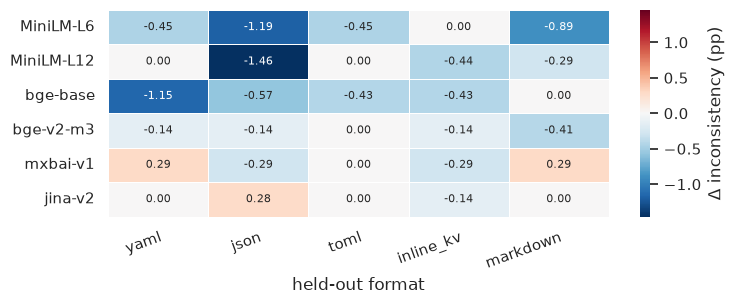

In [14]:
grid = per_fold_matrix(DATA_ROOT, SLUGS, "answer", subset=HELD_OUT)
limit = np.abs(grid.to_numpy()).max()

fig, ax = plt.subplots(figsize=(7.6, 3.2))
sns.heatmap(
    grid,
    annot=True,
    fmt=".2f",
    cmap=DIVERGING,
    center=0,
    vmin=-limit,
    vmax=limit,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"fontsize": 8},
    cbar_kws={"label": "\u0394 inconsistency (pp)"},
    ax=ax,
)
ax.set_xlabel("held-out format")
ax.set_ylabel("")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", rotation_mode="anchor")
save(fig, "per_fold_answer")